In [164]:
"""
This script loads in responses from classification csv file output by Zooniverse,
and normalizes them into a table with one row per task answered
"""
import json
import logging
import sqlite3
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

# PARAMETERS
classifications_csv_path = 'survey_responses/may-survey-classifications_2025-05-19.csv'
output_dir = 'survey_responses/analysis/may'
ml_responses_database_path = 'records_bedrock.db'
subjects_path = 'survey_responses/review-llm-responses-on-lca-tasks-subjects.csv'
workflow_id = 28845

# Load data

In [165]:
current_date = datetime.now().strftime('%Y%m%d')

logging.basicConfig(level=logging.INFO)

# Read classifications
classifications_df = pd.read_csv(classifications_csv_path)
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

subjects_df = pd.read_csv(subjects_path)
# Extract the prompt_id, llm model and other data from the metadata column
subjects_df = subjects_df.loc[subjects_df.workflow_id==workflow_id]
metadata_df = subjects_df['metadata'].apply(json.loads).apply(pd.Series)
subjects_df = pd.concat([subjects_df, metadata_df], axis=1)

# TODO: Prompts and responses in one database
# TODO: filter out questions that were withdrawn
prompts_database_path = 'records_cajetan.db'
conn = sqlite3.connect(prompts_database_path)
prompts_df = pd.read_sql('''select * from prompts''', conn)
ml_responses_database_path = 'records_may_all.db'
conn = sqlite3.connect(ml_responses_database_path)
ml_responses_df = pd.read_sql('select * from responses', conn)


# Plot responses over time

In [166]:
import textwrap
import seaborn as sns
sns.set_theme(style="darkgrid")
# Wrap x-tick labels and rotate
def wrap_labels(ax, width, break_long_words=True):
    xlabels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        parts = text.split('-')
        wrapped_parts = [textwrap.fill(part, width=width, break_long_words=break_long_words) for part in parts]
        wrapped_text = ' '.join(wrapped_parts)
        xlabels.append(wrapped_text)
    ax.set_xticks(ax.get_xticks())  # Set ticks explicitly
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    ylabels=[]
    for label in ax.get_yticklabels():
        text = label.get_text()
        ylabels.append(textwrap.fill(text, width=width, break_long_words=break_long_words))
    ax.set_yticks(ax.get_yticks())  # Set ticks explicitly
    ax.set_yticklabels(ylabels, rotation=45, ha='right')

In [175]:
cumulative_responses

date
2025-05-06      1
2025-05-08      2
2025-05-09      3
2025-05-12     27
2025-05-13     63
2025-05-14     81
2025-05-15    157
2025-05-16    171
2025-05-17    174
2025-05-18    190
2025-05-19    191
dtype: int64

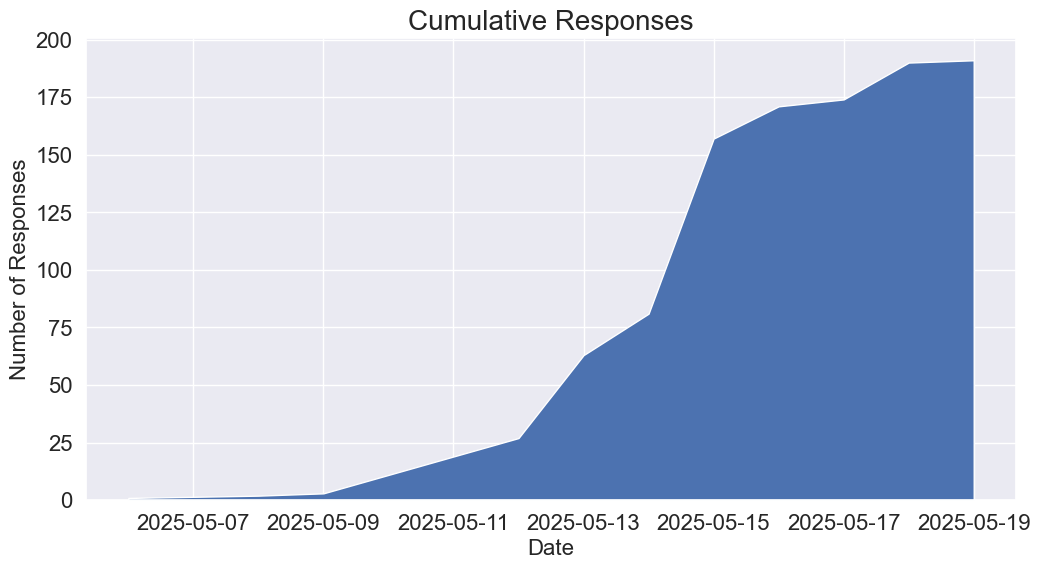

In [181]:
# Plot the cumulative time series
classification_id = classifications_df.classification_id

# Group the data by date and count the number of responses
classifications_df['created_at'] = pd.to_datetime(classifications_df['created_at'])
classifications_df['date'] = classifications_df['created_at'].dt.date
responses_per_day = classifications_df.groupby('date').size()

# Calculate the cumulative sum of responses
cumulative_responses = responses_per_day.cumsum()
plt.figure(figsize=(12, 6))
plt.stackplot(cumulative_responses.index,cumulative_responses.values)
plt.title('Cumulative Responses',fontsize=20)
plt.xlabel('Date',fontsize=16)
plt.ylabel('Number of Responses',fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.savefig(output_dir/'responses_timeline_cum.png')


In [ ]:
from analyze_responses import get_count_completed_tasks

# Count complete answers
classifications_df[['count_completed_tasks', 'final_completed_task_no']] = classifications_df.annotations.apply(
    get_count_completed_tasks)
print('Count completed tasks (note some tasks are optional)')
print(classifications_df.count_completed_tasks.value_counts())
print('Final completed task number')
print(classifications_df.final_completed_task_no.value_counts())


In [6]:
from analyze_responses import explode_tasks

# Combine with the subject data, to get the llm name, the prompt text, etc
# Explode the annotations column
exploded_dfs = classifications_df['annotations'].apply(explode_tasks)
exploded_df = pd.concat(exploded_dfs.values, keys=exploded_dfs.index,
                        names=['original_index', 'task_index']).reset_index(level='task_index', drop=True)
# Pivot the DataFrame to have one column per task
pivoted_df = exploded_df.pivot(columns='task', values='value').reset_index()
# Re-insert the classification_ids
pivoted_df['subject_id'] = classifications_df.loc[pivoted_df['original_index'], 'subject_ids'].values
# Merge and set dtype of prompt_id
combined_df = pivoted_df.merge(subjects_df,on='subject_id',how='inner')
combined_df.prompt_id = combined_df.prompt_id.astype(int)

# Merge with prompts
combined_final = combined_df.merge(prompts_df, on='prompt_id')

# Check if the number of rows in the merged dataframe differs from the number of rows in the left dataframe
if combined_final.shape[0] != combined_df.shape[0]:
    logging.error(
        f"The number of rows in the merged dataframe ({combined_final.shape[0]}) when merging combined_df on prompts_df differs from the number of rows in the left dataframe ({combined_df.shape[0]}).")
    exit()

# Analyse Q2

In [10]:
summary_q2 = combined_final.T2.value_counts()

In [11]:
summary_q2

T2
3 - good                          85
2 - average                       53
1 - poor                          35
4 - expert / better than human    16
Name: count, dtype: int64

In [38]:
# map t2 to numerical values
rating_description_to_number = {"3 - good": 3,
"2 - average": 2,
"1 - poor": 1,
"4 - expert / better than human": 4}

In [39]:
combined_final['T2_score']=combined_final['T2'].apply(lambda x: rating_description_to_number[x])

In [45]:
combined_final.columns

Index(['original_index', 'T1', 'T10', 'T11', 'T12', 'T2', 'T3', 'T4', 'T6',
       'T7', 'T8', 'T9', 'subject_id', 'project_id', 'workflow_id',
       'subject_set_id', 'metadata', 'locations', 'classifications_count',
       'retired_at', 'retirement_reason', 'created_at', 'updated_at',
       '#date_run', 'prompt_id', '#llm_model', 'response_id', '#temperature',
       '#llm_provider', '#prompt_run_by', 'prompt_text', 'T2_score'],
      dtype='object')

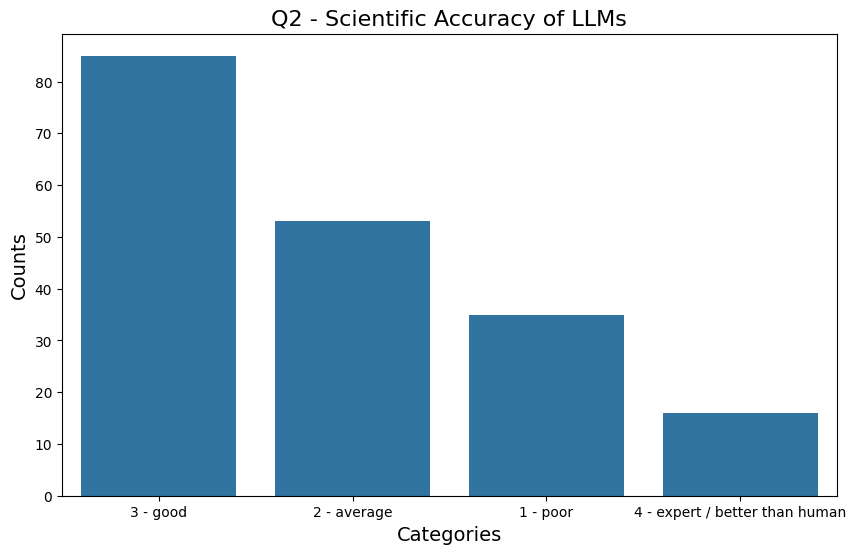

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=summary_q2.index, y=summary_q2.values)
plt.title('Q2 - Scientific Accuracy of LLMs',fontsize=16)
plt.xlabel('Categories',fontsize=14)
plt.ylabel('Counts',fontsize=14)
plt.show()

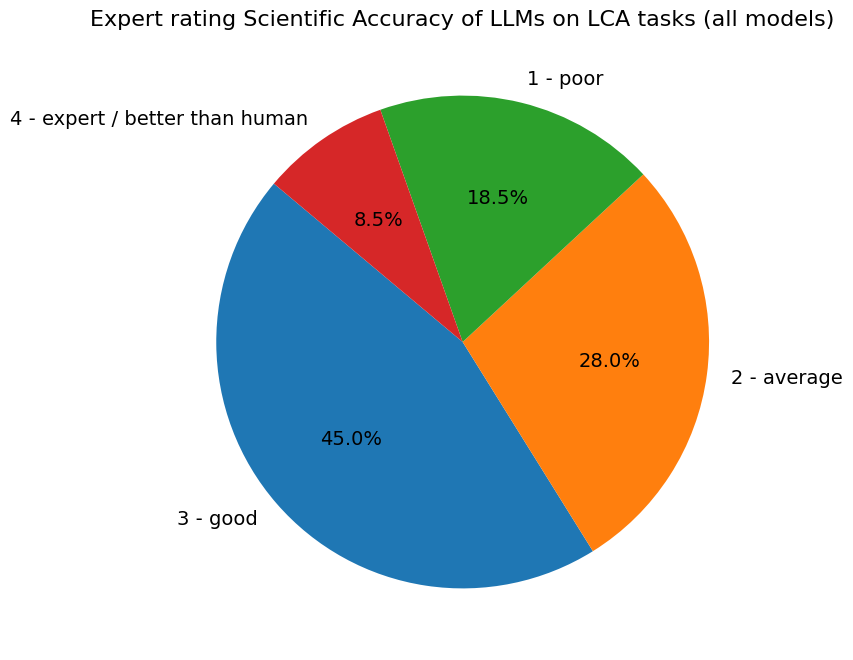

In [55]:
# Pie Chart with larger text
plt.figure(figsize=(8, 8))
plt.pie(summary_q2.values, labels=summary_q2.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 14})
plt.title('Expert rating Scientific Accuracy of LLMs on LCA tasks (all models)', fontsize=16)
plt.show()

In [47]:
q2_by_model = combined_final.groupby(['#llm_model', 'T2_score']).size().unstack(fill_value=0)

In [48]:
q2_by_model

T2_score,1,2,3,4
#llm_model,,,,
gemini/gemini-2.0-flash-001,1,3,3,4
mistral/mistral-large-2411,3,6,8,0
ollama_chat/deepseek-r1:8b,6,7,7,0
ollama_chat/gemma3:27b,3,2,4,0
ollama_chat/phi4:latest,3,3,8,0
ollama_chat/qwen3:30b,3,5,5,5
openai/gpt-4.1,0,6,15,2
us.amazon.nova-premier-v1:0,2,5,7,1
us.anthropic.claude-3-7-sonnet-20250219-v1:0,4,3,8,0


In [86]:
model_t2_mean = combined_final.groupby('#llm_model')['T2_score'].mean().sort_values(ascending=False)
print(model_t2_mean)


#llm_model
gemini/gemini-2.0-flash-001                     2.909091
openai/gpt-4.1                                  2.826087
ollama_chat/qwen3:30b                           2.666667
us.meta.llama4-scout-17b-instruct-v1:0          2.615385
us.amazon.nova-premier-v1:0                     2.466667
ollama_chat/phi4:latest                         2.357143
us.meta.llama4-maverick-17b-instruct-v1:0       2.312500
mistral/mistral-large-2411                      2.294118
us.deepseek.r1-v1:0                             2.277778
us.anthropic.claude-3-7-sonnet-20250219-v1:0    2.266667
ollama_chat/gemma3:27b                          2.111111
ollama_chat/deepseek-r1:8b                      2.050000
Name: T2_score, dtype: float64


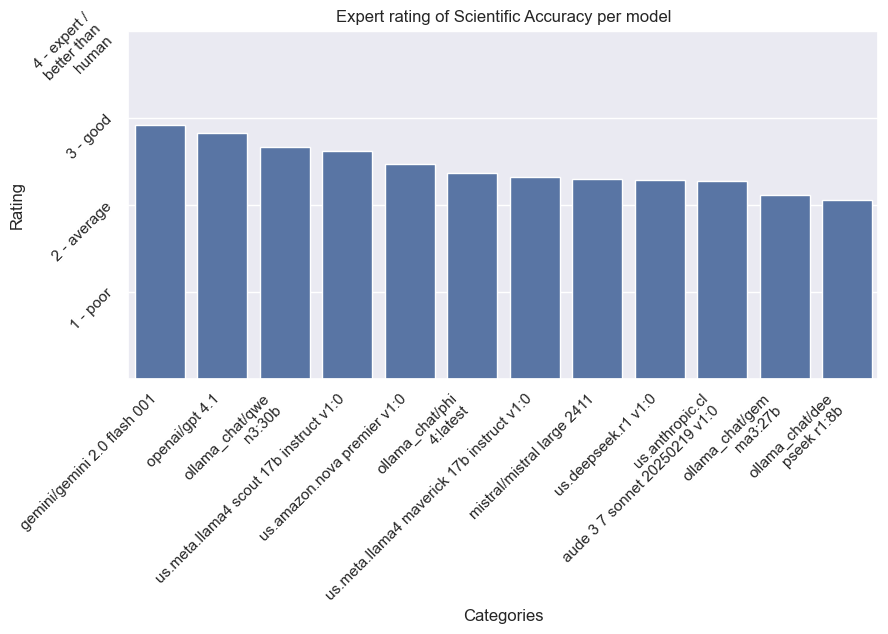

In [99]:



# Count Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=model_t2_mean.index,y=model_t2_mean.values)
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(list(rating_description_to_number.values()), list(rating_description_to_number.keys()))


plt.subplots_adjust(left=0.15, bottom=0.3)
wrap_labels(plt.gca(), width=15)

plt.savefig(output_dir/f'{current_date}_q2_scientific_accuracy_per_model.png')
plt.show()



# The same, but take the median

In [100]:
model_t2_median = combined_final.groupby('#llm_model')['T2_score'].median().sort_values(ascending=False)
print(model_t2_mean)


#llm_model
gemini/gemini-2.0-flash-001                     2.909091
openai/gpt-4.1                                  2.826087
ollama_chat/qwen3:30b                           2.666667
us.meta.llama4-scout-17b-instruct-v1:0          2.615385
us.amazon.nova-premier-v1:0                     2.466667
ollama_chat/phi4:latest                         2.357143
us.meta.llama4-maverick-17b-instruct-v1:0       2.312500
mistral/mistral-large-2411                      2.294118
us.deepseek.r1-v1:0                             2.277778
us.anthropic.claude-3-7-sonnet-20250219-v1:0    2.266667
ollama_chat/gemma3:27b                          2.111111
ollama_chat/deepseek-r1:8b                      2.050000
Name: T2_score, dtype: float64


In [ ]:
import textwrap
sns.set_theme(style="darkgrid")

# Count Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=model_t2_mean.index,y=model_t2_mean.values)
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(list(rating_description_to_number.values()), list(rating_description_to_number.keys()))


plt.subplots_adjust(left=0.15, bottom=0.3)
wrap_labels(plt.gca(), width=15)

plt.savefig(output_dir/f'{current_date}_q2_scientific_accuracy_per_model_median.png')
plt.show()



# Violin plot

In [124]:
# Add count of datapoints per model to combined_df
counts_per_model = combined_final.groupby('#llm_model').T2.agg(len).to_dict()

combined_final['data_points_per_model'] = combined_final['#llm_model'].apply(lambda x: counts_per_model[x])

C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 26.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 34.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarni

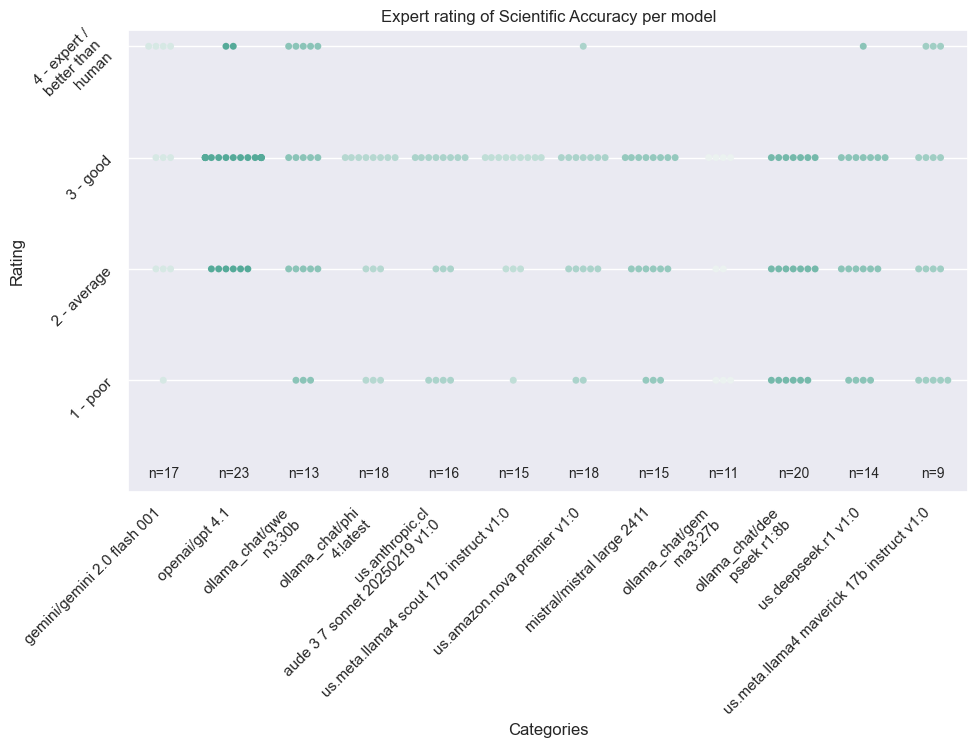

In [190]:
import numpy as np

def convert_dict_to_sorted_list(input_dict):
    # Sort the keys based on their values
    sorted_keys = sorted(input_dict, key=input_dict.get)
    return sorted_keys
ylabels_text = convert_dict_to_sorted_list(rating_description_to_number)
ylabels_text.insert(0,'')
# Violin Plot

plt.figure(figsize=(12, 6))

colors = sns.color_palette("light:#5A9", as_cmap=True)

ax = sns.swarmplot(x='#llm_model', y='T2_score', data=combined_final,order=list(model_t2_median.index),hue='data_points_per_model',palette=colors)
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(np.arange(0,5,1), ylabels_text)

# Rotate x-tick labels and adjust alignment
plt.xticks(rotation=45, ha='right')
wrap_labels(plt.gca(), width=15)


# Add number of data points to each bar
for i, model in enumerate(combined_final['#llm_model'].unique()):
    count = combined_final[combined_final['#llm_model'] == model]['T2_score'].count()
    ax.text(i, ax.get_ylim()[0] + 0.1, f'n={count}', ha='center', va='bottom', fontsize=10)

ax.get_legend().remove()
plt.subplots_adjust(left=0.15, right=0.85)
plt.savefig(output_dir/f'{current_date}_q2_scientific_accuracy_per_model_violin.png')

plt.show()

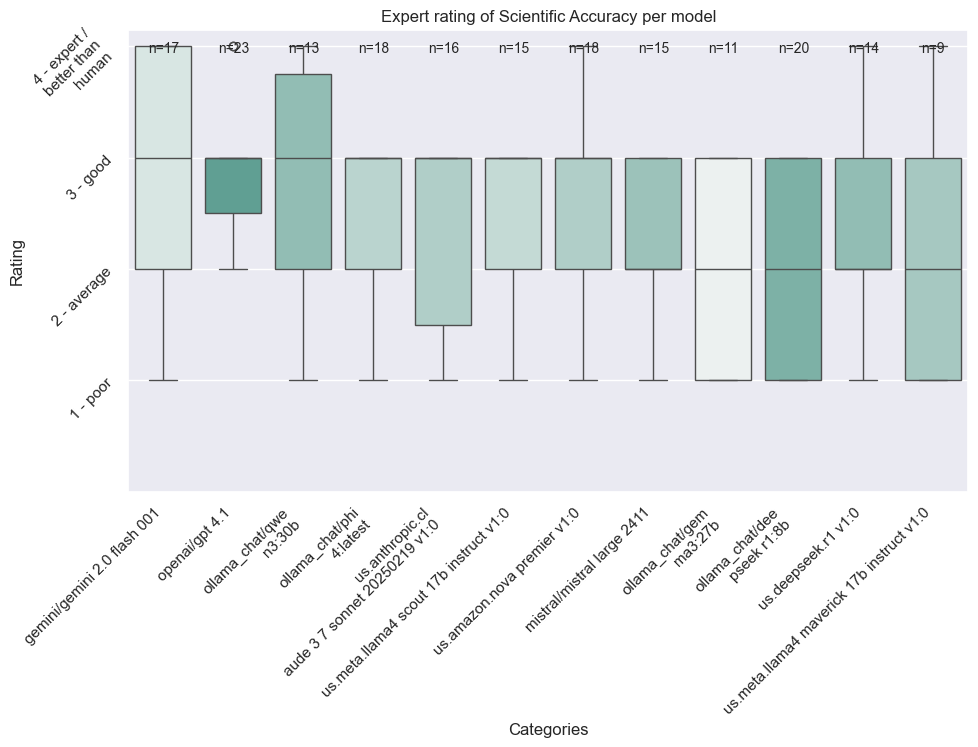

In [182]:
import numpy as np

def convert_dict_to_sorted_list(input_dict):
    # Sort the keys based on their values
    sorted_keys = sorted(input_dict, key=input_dict.get)
    return sorted_keys

ylabels_text = convert_dict_to_sorted_list(rating_description_to_number)
ylabels_text.insert(0, '')

# Whisker Plot
plt.figure(figsize=(12, 6))

colors = sns.color_palette("light:#5A9", as_cmap=True)

ax = sns.boxplot(x='#llm_model', y='T2_score', data=combined_final, order=list(model_t2_median.index), hue='data_points_per_model', palette=colors)
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(np.arange(0, 5, 1), ylabels_text)

# Rotate x-tick labels and adjust alignment
plt.xticks(rotation=45, ha='right')
wrap_labels(plt.gca(), width=15)

# Add number of data points to each bar
for i, model in enumerate(combined_final['#llm_model'].unique()):
    count = combined_final[combined_final['#llm_model'] == model]['T2_score'].count()
    ax.text(i, ax.get_ylim()[1] - 0.1, f'n={count}', ha='center', va='top', fontsize=10)

ax.get_legend().remove()
plt.subplots_adjust(left=0.15, right=0.85)
plt.savefig(output_dir / f'{current_date}_q2_scientific_accuracy_per_model_whisker.png')

plt.show()

In [144]:
ylabels_text

['', '1 - poor', '2 - average', '3 - good', '4 - expert / better than human']